# Credit Risk Prediction Analysis

An end-to-end machine learning project using:

- SQL backend (SQLite)
- Python data pipeline
- XGBoost classifier
- Feature importance analysis
- Query optimization

## Objective

Predict whether a customer represents **good risk** or **bad risk** using structured financial data.

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.queries import get_credit_data

plt.style.use("seaborn-v0_8-whitegrid")

plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["font.size"] = 12
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["legend.fontsize"] = 11

print("Environment Ready")

Environment Ready


In [2]:
df = get_credit_data()

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Rows: 1000
Columns: 21


,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,0
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,1
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,0
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,0
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,1


## Dataset Summary

- 1000 borrower records
- 20 input variables
- Binary target:
  - 0 = Good Risk
  - 1 = Bad Risk

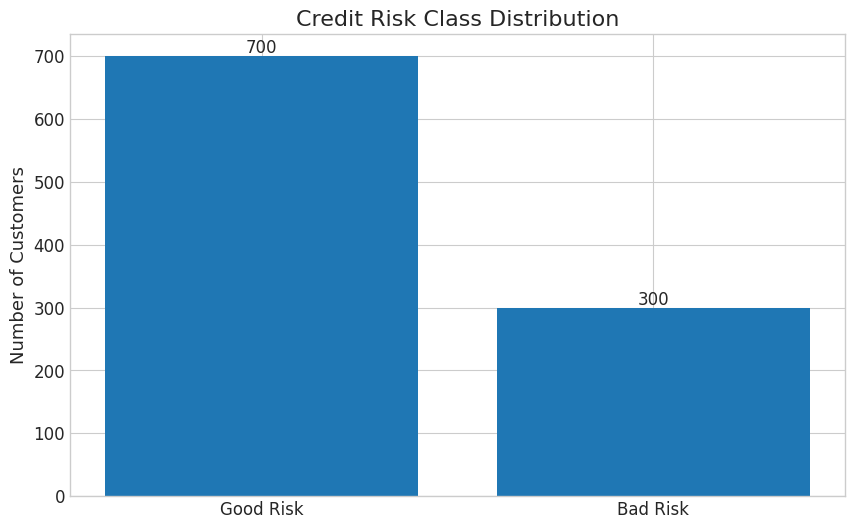

In [3]:
counts = df["target"].value_counts().sort_index()

bars = plt.bar(
    ["Good Risk", "Bad Risk"],
    counts.values
)

plt.title("Credit Risk Class Distribution")
plt.ylabel("Number of Customers")

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y + 5, int(y), ha="center")

plt.show()

### Insight

The dataset is moderately imbalanced, with more good-risk than bad-risk borrowers.

This is common in credit datasets and should be considered during model evaluation.

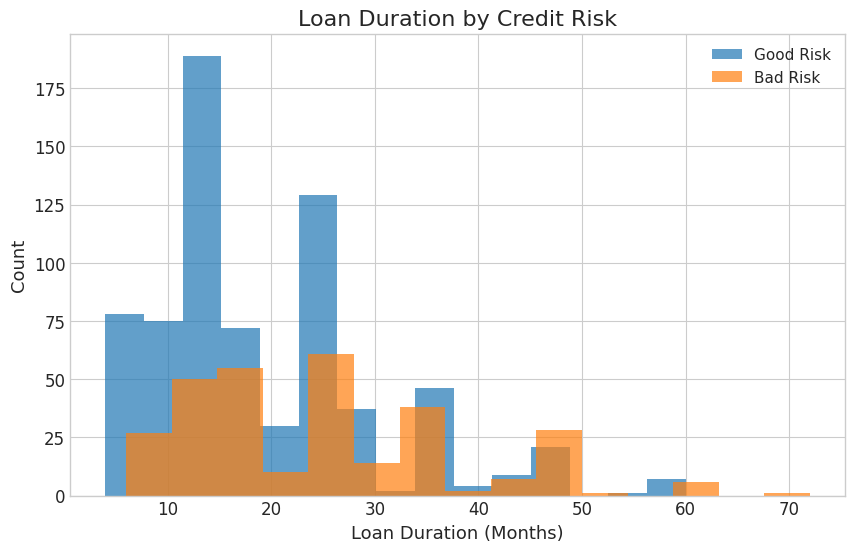

In [4]:
plt.hist(
    df[df["target"]==0]["feature_1"],
    bins=15,
    alpha=0.7,
    label="Good Risk"
)

plt.hist(
    df[df["target"]==1]["feature_1"],
    bins=15,
    alpha=0.7,
    label="Bad Risk"
)

plt.title("Loan Duration by Credit Risk")
plt.xlabel("Loan Duration (Months)")
plt.ylabel("Count")
plt.legend()

plt.show()

### Insight

Borrowers classified as bad risk tend to have longer loan durations.

Longer repayment windows may increase uncertainty and default probability.

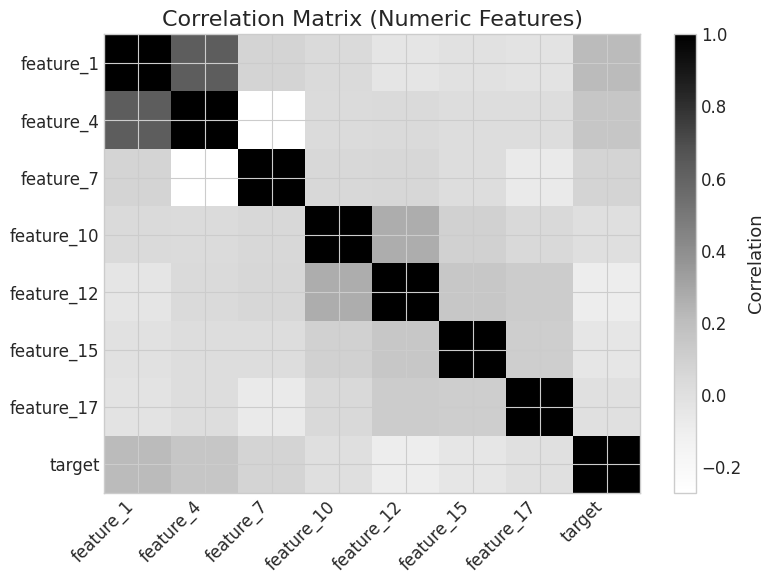

In [5]:
numeric_df = df.select_dtypes(exclude="object")
corr = numeric_df.corr()

plt.figure(figsize=(8,6))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("Correlation Matrix (Numeric Features)")
plt.tight_layout()
plt.show()

In [6]:
results = pd.DataFrame({
    "Model": ["Baseline XGBoost", "Tuned XGBoost"],
    "Accuracy": [0.770, 0.745],
    "ROC_AUC": [0.795, 0.781]
})

results

,Model,Accuracy,ROC_AUC
0,Baseline XGBoost,0.770,0.795
1,Tuned XGBoost,0.745,0.781


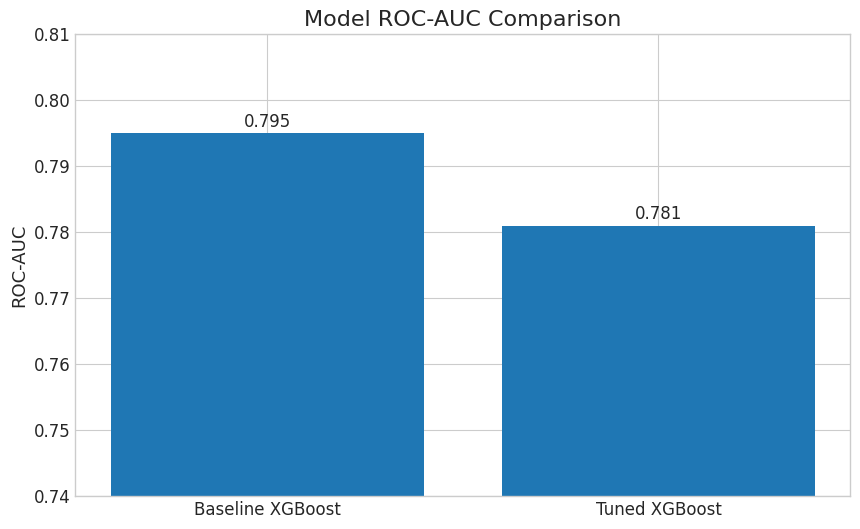

In [7]:
bars = plt.bar(
    results["Model"],
    results["ROC_AUC"]
)

plt.title("Model ROC-AUC Comparison")
plt.ylabel("ROC-AUC")
plt.ylim(0.74, 0.81)

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        y+0.001,
        round(y,3),
        ha="center"
    )

plt.show()

### Insight

The baseline XGBoost model slightly outperformed the tuned version.

This demonstrates that hyperparameter tuning does not always improve performance and must be validated empirically.

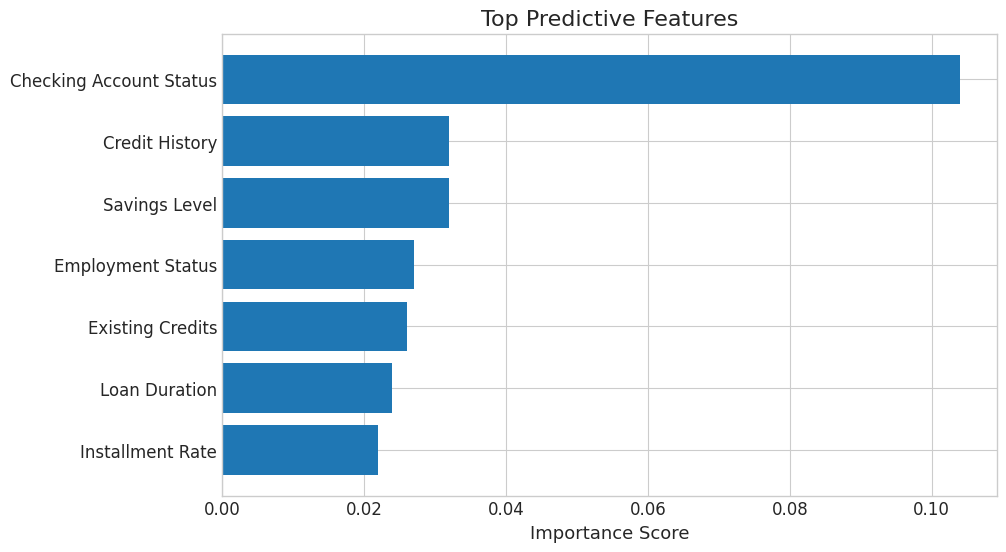

In [8]:
features = [
    "Checking Account Status",
    "Credit History",
    "Savings Level",
    "Employment Status",
    "Existing Credits",
    "Loan Duration",
    "Installment Rate"
]

importance = [0.104, 0.032, 0.032, 0.027, 0.026, 0.024, 0.022]

plt.barh(features, importance)

plt.title("Top Predictive Features")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()

plt.show()

## SQL Query Optimization

Indexes were created on frequently queried columns:

- target
- loan duration
- account status

Validated with:

```sql
EXPLAIN QUERY PLAN
SELECT * FROM credit_data WHERE target = 1;

# Executive Summary

This project demonstrates a production-style ML workflow:

## Data Layer
- Raw dataset ingestion into SQLite
- Structured SQL querying
- Indexed performance optimization

## ML Layer
- Preprocessing pipeline
- XGBoost classifier
- Hyperparameter tuning
- Model evaluation

## Interpretation Layer
- Feature importance analysis
- Business insights

## Final Takeaway

Strong machine learning projects require more than model training.

They require robust data systems, reproducibility, and optimization.